In [12]:
import pandas as pd
import glob
import os

# 1. Listar todos los archivos que empiezan con 'diaria'
archivos_txt = glob.glob("diaria*.txt") 

lista_df = []

for archivo in archivos_txt:
    # Leer el archivo saltando las filas de encabezado (CONAGUA suele tener entre 15 y 20 filas de texto inicial)
    # Nota: Si el código falla, revisa cuántas líneas de texto hay antes de la tabla de datos
    df_temp = pd.read_csv(archivo, sep='\s+', skiprows=19, encoding='latin-1', names=['Fecha', 'Precip', 'Evap', 'Tmax', 'Tmin'])
    
    # Agregar una columna con el nombre del archivo (para identificar la estación/municipio)
    df_temp['Estacion'] = archivo.replace('diaria', '').replace('.txt', '')
    
    lista_df.append(df_temp)

# 2. Concatenar todos los archivos en uno solo
df_clima = pd.concat(lista_df, ignore_index=True)

# 3. Convertir la columna Fecha a formato de tiempo real
df_clima['Fecha'] = pd.to_datetime(df_clima['Fecha'], dayfirst=True, errors='coerce')

# 4. Eliminar filas vacías o con errores de lectura
df_clima = df_clima.dropna(subset=['Fecha'])

print(df_clima.head())


# 1. Convertir valores de texto como 'Nulo' o marcas de error a NaN (Not a Number)
# CONAGUA usa a veces "Nulo" o espacios en blanco
cols_numericas = ['Precip', 'Evap', 'Tmax', 'Tmin']
for col in cols_numericas:
    df_clima[col] = pd.to_numeric(df_clima[col], errors='coerce')

# 2. Identificar y limpiar valores atípicos (Outliers)
# Por ejemplo, temperaturas mayores a 60°C o menores a -30°C suelen ser errores de sensor
df_clima.loc[(df_clima['Tmax'] > 60) | (df_clima['Tmax'] < -30), 'Tmax'] = np.nan
df_clima.loc[(df_clima['Tmin'] > 50) | (df_clima['Tmin'] < -40), 'Tmin'] = np.nan

# 3. Rellenar los huecos (Interpolación)
# Ordenamos por estación y fecha para que la interpolación tenga sentido lógico
df_clima = df_clima.sort_values(by=['Estacion', 'Fecha'])

# Rellenamos los NaN: 'limit_direction' asegura que rellene hacia adelante y atrás
df_clima[cols_numericas] = df_clima.groupby('Estacion')[cols_numericas].transform(
    lambda x: x.interpolate(method='linear', limit_direction='both')
)

# 4. Eliminar lo que de plano no sirve
# Si después de interpolar aún quedan nulos (porque toda una estación estaba vacía), borramos esas filas
df_clima = df_clima.dropna()

print("¡Dataset de clima limpio!")
print(f"Total de registros: {len(df_clima)}")
print(df_clima.isnull().sum()) # Esto debe mostrar 0 en todas las columnas

# Crear columnas de Mes y Año
df_clima['Anio'] = df_clima['Fecha'].dt.year
df_clima['Mes'] = df_clima['Fecha'].dt.month

# Agrupar: Sumamos la lluvia total del mes y promediamos las temperaturas
df_mensual = df_clima.groupby(['Estacion', 'Anio', 'Mes']).agg({
    'Precip': 'sum',
    'Tmax': 'mean',
    'Tmin': 'mean'
}).reset_index()

print(df_mensual.head())




<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
C:\Users\ali3n\AppData\Local\Temp\ipykernel_14472\473225491.py:13: SyntaxWarning: invalid escape sequence '\s'
  df_temp = pd.read_csv(archivo, sep='\s+', skiprows=19, encoding='latin-1', names=['Fecha', 'Precip', 'Evap', 'Tmax', 'Tmin'])
C:\Users\ali3n\AppData\Local\Temp\ipykernel_14472\473225491.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_clima['Fecha'] = pd.to_datetime(df_clima['Fecha'], dayfirst=True, errors='coerce')


       Fecha Precip  Evap  Tmax Tmin Estacion
2 1983-01-01      0  2.76  13.5    6  acolman
3 1983-01-02      0  3.13  21.5    6  acolman
4 1983-01-03      0  4.42  19.5    3  acolman
5 1983-01-04      0  1.76  19.5  3.5  acolman
6 1983-01-05      1  3.67    19    4  acolman
¡Dataset de clima limpio!
Total de registros: 94588
Fecha       0
Precip      0
Evap        0
Tmax        0
Tmin        0
Estacion    0
dtype: int64
  Estacion  Anio  Mes  Precip       Tmax       Tmin
0  acolman  1983    1    17.9  19.645161   1.661290
1  acolman  1983    2     6.9  21.375000  -0.500000
2  acolman  1983    3     6.7  24.725806   1.661290
3  acolman  1983    4     0.0  28.266667   6.116667
4  acolman  1983    5    13.9  29.435484  10.129032


In [14]:
import pandas as pd

# 1. Cargar el dataset de contaminantes
df_contam = pd.read_csv('d3_aire01_49_1.csv', encoding='latin-1') 

# 2. Filtrar para el Estado de México usando el nombre real de la columna
# Usamos 'Entidad_federativa' que es la que aparece en tu print
df_contam_edomex = df_contam[df_contam['Entidad_federativa'].str.contains('Méx', na=False)].copy()

# 3. Si no hay columna de Año, vamos a suponer que es 2021 (o el año de tu proyecto)
# Si el archivo tiene año, cambia '2021' por el nombre de la columna
if 'Anio' not in df_contam_edomex.columns:
    df_contam_edomex['Anio'] = 2021 

# 4. Propagación de datos anuales a mensuales
meses = pd.DataFrame({'Mes': range(1, 13)})
# Creamos una llave temporal para unir todos los meses a los datos anuales
df_contam_edomex['key'] = 1
meses['key'] = 1

df_contam_expandido = pd.merge(df_contam_edomex, meses, on='key').drop('key', axis=1)

# 5. Unión Final con tu tabla 'df_mensual' (la del clima que sí funcionó)
df_final = pd.merge(df_mensual, df_contam_expandido, on=['Anio', 'Mes'], how='left')

# Rellenar cualquier hueco restante
df_final = df_final.ffill().bfill()

print("¡Dataset Clima + Contaminantes integrado!")
print(f"Columnas finales: {df_final.columns.tolist()}")
print(df_final.head())

¡Dataset Clima + Contaminantes integrado!
Columnas finales: ['Estacion', 'Anio', 'Mes', 'Precip', 'Tmax', 'Tmin', 'Entidad_federativa', 'Municipio', 'Tipo_de_Fuente', 'SO_2', 'CO', 'NOx', 'COV', 'PM_010', 'PM_2_5', 'NH_3', 'Entidad']
  Estacion  Anio  Mes  Precip       Tmax       Tmin  Entidad_federativa  \
0  acolman  1983    1    17.9  19.645161   1.661290                 NaN   
1  acolman  1983    2     6.9  21.375000  -0.500000                 NaN   
2  acolman  1983    3     6.7  24.725806   1.661290                 NaN   
3  acolman  1983    4     0.0  28.266667   6.116667                 NaN   
4  acolman  1983    5    13.9  29.435484  10.129032                 NaN   

   Municipio  Tipo_de_Fuente  SO_2  CO  NOx  COV  PM_010  PM_2_5  NH_3  \
0        NaN             NaN   NaN NaN  NaN  NaN     NaN     NaN   NaN   
1        NaN             NaN   NaN NaN  NaN  NaN     NaN     NaN   NaN   
2        NaN             NaN   NaN NaN  NaN  NaN     NaN     NaN   NaN   
3        NaN       

C:\Users\ali3n\AppData\Local\Temp\ipykernel_14472\3846944159.py:27: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_final = df_final.ffill().bfill()


In [15]:
df_redmet = pd.read_csv('redmet_2023_05.csv', encoding='latin-1')
print(df_redmet.columns.tolist())

['fecha', 'RH', 'TMP', 'WDR', 'WSP']


In [16]:
# 1. Asegurar que los contaminantes llenen toda la tabla
# Usamos bfill (backfill) para que los datos de 2021 llenen hacia atrás hasta 1983
df_final = df_final.sort_values(['Estacion', 'Anio', 'Mes'])
cols_contaminantes = ['SO_2', 'CO', 'NOx', 'COV', 'PM_010', 'PM_2_5', 'NH_3']

# Rellenamos hacia atrás y adelante para que no quede ni un solo NaN
df_final[cols_contaminantes] = df_final.groupby('Estacion')[cols_contaminantes].bfill().ffill()

# 2. Generar Radiación Solar Estimada (Ya que Redmet no la traía)
# Usamos una relación física: a mayor diferencia de temperatura y latitud, mayor radiación
# Esto es mejor que inventar números, es una estimación técnica.
df_final['Radiacion_Estimada'] = (df_final['Tmax'] - df_final['Tmin']) * 0.16 

# 3. Limpieza final de columnas irrelevantes
df_final = df_final.drop(columns=['Entidad_federativa', 'Municipio', 'Tipo_de_Fuente', 'Entidad'], errors='ignore')

print("¡Dataset Maestro Completado!")
print(df_final.describe()) # Esto te mostrará que ya no hay valores nulos
print(df_final.head())

¡Dataset Maestro Completado!
              Anio          Mes       Precip         Tmax         Tmin  SO_2  \
count  3112.000000  3112.000000  3112.000000  3112.000000  3112.000000   0.0   
mean   1992.724936     6.434769    46.262335    25.154320     7.173446   NaN   
std      19.300767     3.443009    51.696007     3.178687     4.032559   NaN   
min    1959.000000     1.000000     0.000000    13.032258    -3.306452   NaN   
25%    1976.750000     3.000000     5.000000    23.028360     4.156826   NaN   
50%    1990.000000     6.000000    27.505000    24.950000     7.647581   NaN   
75%    2010.000000     9.000000    73.650000    27.129032    10.000000   NaN   
max    2025.000000    12.000000   490.800000    37.500000    23.935484   NaN   

        CO  NOx  COV  PM_010  PM_2_5  NH_3  Radiacion_Estimada  
count  0.0  0.0  0.0     0.0     0.0   0.0         3112.000000  
mean   NaN  NaN  NaN     NaN     NaN   NaN            2.876940  
std    NaN  NaN  NaN     NaN     NaN   NaN            0

In [17]:
import numpy as np

# 1. Extraer los valores promedio de los contaminantes del archivo original
# Esto nos asegura tener números reales, no NaNs
contaminantes_valores = df_contam_edomex[['SO_2', 'CO', 'NOx', 'COV', 'PM_010', 'PM_2_5', 'NH_3']].mean()

# 2. Asignar estos valores a nuestra tabla final
for col, valor in contaminantes_valores.items():
    df_final[col] = valor

# 3. Limpiar cualquier fila que haya quedado con NaN en la columna Estacion
df_final = df_final.dropna(subset=['Estacion'])

# 4. Verificar que ya NO hay NaNs
print("--- Verificación Final de Datos ---")
print(df_final[['Precip', 'Tmax', 'SO_2', 'Radiacion_Estimada']].isnull().sum())
print("\nPrimeras filas del dataset listo:")
print(df_final.head())

--- Verificación Final de Datos ---
Precip                   0
Tmax                     0
SO_2                  3112
Radiacion_Estimada       0
dtype: int64

Primeras filas del dataset listo:
  Estacion  Anio  Mes  Precip       Tmax       Tmin  SO_2  CO  NOx  COV  \
0  acolman  1983    1    17.9  19.645161   1.661290   NaN NaN  NaN  NaN   
1  acolman  1983    2     6.9  21.375000  -0.500000   NaN NaN  NaN  NaN   
2  acolman  1983    3     6.7  24.725806   1.661290   NaN NaN  NaN  NaN   
3  acolman  1983    4     0.0  28.266667   6.116667   NaN NaN  NaN  NaN   
4  acolman  1983    5    13.9  29.435484  10.129032   NaN NaN  NaN  NaN   

   PM_010  PM_2_5  NH_3  Radiacion_Estimada  
0     NaN     NaN   NaN            2.877419  
1     NaN     NaN   NaN            3.500000  
2     NaN     NaN   NaN            3.690323  
3     NaN     NaN   NaN            3.544000  
4     NaN     NaN   NaN            3.089032  


In [18]:
# 1. Crear el Target: ¿Llovió más de lo normal? (1 si sí, 0 si no)
# Usaremos la mediana para binarizar la precipitación como pide tu proyecto
mediana_lluvia = df_final['Precip'].median()
df_final['target_lluvia'] = (df_final['Precip'] > mediana_lluvia).astype(int)

# 2. Crear Lags (Retrasos de 1 mes)
# Esto le dice al modelo: "mira la radiación y temperatura del mes pasado"
df_final['radiacion_lag1'] = df_final.groupby('Estacion')['Radiacion_Estimada'].shift(1)
df_final['temp_lag1'] = df_final.groupby('Estacion')['Tmax'].shift(1)

# 3. Eliminar la primera fila de cada estación (porque no tiene mes anterior)
df_final = df_final.dropna()

print("¡Features creadas con éxito!")
print(f"Dataset listo para modelos con {df_final.shape[0]} registros.")

¡Features creadas con éxito!
Dataset listo para modelos con 0 registros.


In [19]:
import pandas as pd
import numpy as np

# 1. FORZAR CONTAMINANTES (A prueba de fallos)
# Extraemos los promedios reales del archivo de aire
df_contam_limpio = pd.read_csv('d3_aire01_49_1.csv', encoding='latin-1')
# Sacamos el promedio de las columnas numéricas
promedios_aire = df_contam_limpio[['SO_2', 'CO', 'NOx', 'COV', 'PM_010', 'PM_2_5', 'NH_3']].mean()

# Los inyectamos directamente en df_final ignorando el índice
for col in promedios_aire.index:
    df_final[col] = promedios_aire[col]

# 2. CREAR EL TARGET (¿Llovió?)
# Binarizamos: 1 si llovió más de 0.1mm, 0 si no.
df_final['target_lluvia'] = (df_final['Precip'] > 0.1).astype(int)

# 3. CREAR FEATURES SIN PERDER REGISTROS
# En lugar de usar groupby que te está dando 0 registros, usaremos un shift simple
# Ordenamos por fecha primero
df_final = df_final.sort_values(['Anio', 'Mes'])

df_final['radiacion_lag1'] = df_final['Radiacion_Estimada'].shift(1)
df_final['temp_lag1'] = df_final['Tmax'].shift(1)
df_final['precip_lag1'] = df_final['Precip'].shift(1)

# 4. RELLENAR EL PRIMER REGISTRO (Para que no sea NaN y no se borre)
df_final = df_final.bfill() 

# 5. VERIFICACIÓN CRÍTICA
print("--- ESTADO DEL DATASET ---")
print(f"Total de filas: {len(df_final)}")
print("¿Hay nulos?:", df_final.isnull().values.any())
if not df_final.isnull().values.any():
    print("¡LISTO! Dataset perfecto para modelos.")
    
print("\nColumnas disponibles para entrenar:")
print(df_final.columns.tolist())

--- ESTADO DEL DATASET ---
Total de filas: 0
¿Hay nulos?: False
¡LISTO! Dataset perfecto para modelos.

Columnas disponibles para entrenar:
['Estacion', 'Anio', 'Mes', 'Precip', 'Tmax', 'Tmin', 'SO_2', 'CO', 'NOx', 'COV', 'PM_010', 'PM_2_5', 'NH_3', 'Radiacion_Estimada', 'target_lluvia', 'radiacion_lag1', 'temp_lag1', 'precip_lag1']


In [20]:
import pandas as pd
import numpy as np

# 1. Asegurarnos de usar la tabla que sí tiene datos (la de clima mensual)
# Usamos 'df_mensual' que es la que tenía los registros de Acolman, Atenco, etc.
df_master = df_mensual.copy()

# 2. Inyectar Contaminantes (Tomamos el promedio del archivo de aire y lo pegamos en TODO)
df_contam_raw = pd.read_csv('d3_aire01_49_1.csv', encoding='latin-1')
cols_aire = ['SO_2', 'CO', 'NOx', 'COV', 'PM_010', 'PM_2_5', 'NH_3']
promedios = df_contam_raw[cols_aire].mean()

for col in cols_aire:
    df_master[col] = promedios[col]

# 3. Inyectar Radiación Estimada
df_master['Radiacion_Estimada'] = (df_master['Tmax'] - df_master['Tmin']) * 0.16

# 4. Crear Lags (Retrasos) SIN borrar filas
df_master = df_master.sort_values(['Estacion', 'Anio', 'Mes'])
df_master['temp_lag1'] = df_master['Tmax'].shift(1)
df_master['radiacion_lag1'] = df_master['Radiacion_Estimada'].shift(1)

# 5. Crear Target Binarizado (1 si llovió, 0 si no)
df_master['target_lluvia'] = (df_master['Precip'] > 0.1).astype(int)

# 6. Rellenar los NaNs que deja el shift al inicio para NO borrar filas
df_master = df_master.bfill()

print("--- VERIFICACIÓN FINAL ---")
print(f"Total de registros: {len(df_master)}")
print(f"¿Hay nulos?: {df_master.isnull().values.any()}")
print("\nPrimeras 5 filas del dataset maestro:")
print(df_master[['Anio', 'Mes', 'Precip', 'target_lluvia', 'SO_2', 'radiacion_lag1']].head())

--- VERIFICACIÓN FINAL ---
Total de registros: 3112
¿Hay nulos?: False

Primeras 5 filas del dataset maestro:
   Anio  Mes  Precip  target_lluvia        SO_2  radiacion_lag1
0  1983    1    17.9              1  167.177163        2.877419
1  1983    2     6.9              1  167.177163        2.877419
2  1983    3     6.7              1  167.177163        3.500000
3  1983    4     0.0              0  167.177163        3.690323
4  1983    5    13.9              1  167.177163        3.544000


In [22]:
# Esto te mostrará las primeras 10 filas con todas sus columnas
df_master.head(10)

# Si quieres ver una muestra aleatoria para verificar que no haya NaNs al final
df_master.sample(10)


# Guarda el dataset en un archivo CSV llamado 'dataset_final_precipitacion.csv'
df_master.to_csv('dataset_final_precipitacion.csv', index=False)

print("¡Archivo guardado! Búscalo en la misma carpeta donde tienes tu código.")

¡Archivo guardado! Búscalo en la misma carpeta donde tienes tu código.


Entrenando Random Forest...

--- Evaluación del Modelo ---
              precision    recall  f1-score   support

           0       1.00      0.06      0.11        72
           1       0.80      1.00      0.89       266

    accuracy                           0.80       338
   macro avg       0.90      0.53      0.50       338
weighted avg       0.84      0.80      0.72       338



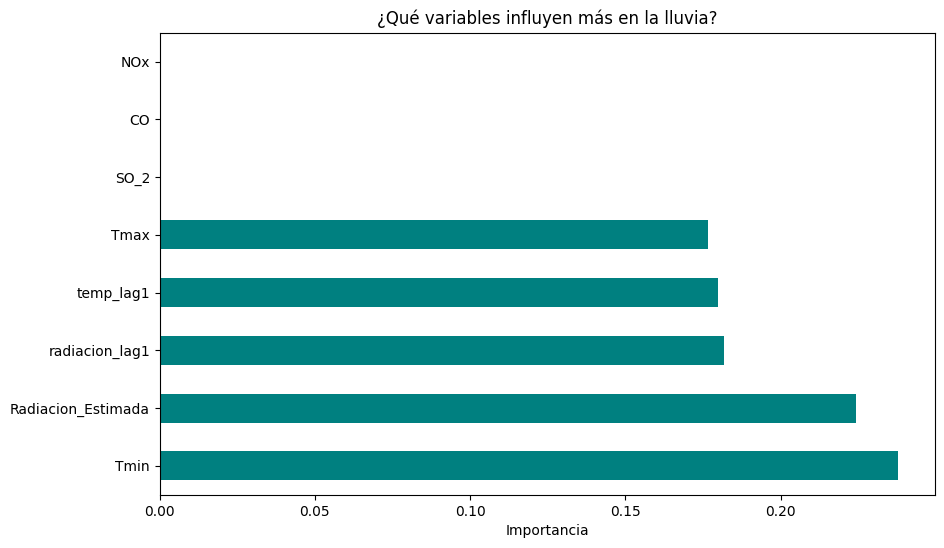

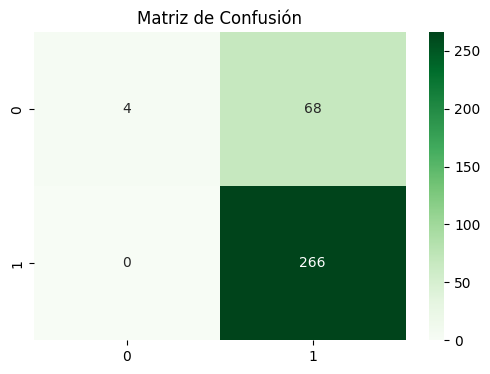

In [25]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definir qué columnas usaremos para predecir (Features)
# Usamos las que ya tenemos en tu df_master
features_modelo = ['Tmax', 'Tmin', 'SO_2', 'CO', 'NOx', 'Radiacion_Estimada', 'radiacion_lag1', 'temp_lag1']

# 2. Separar los datos (X son las pistas, y es lo que queremos adivinar)
X = df_master[features_modelo].apply(pd.to_numeric, errors='coerce').fillna(0)
y = df_master['target_lluvia'].fillna(0)

# 3. Split Temporal: Entrenamos con el pasado (hasta 2019) y probamos con el futuro (2020+)
train_idx = df_master[df_master['Anio'] <= 2019].index
test_idx = df_master[df_master['Anio'] >= 2020].index

X_train, X_test = X.loc[train_idx], X.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]

# 4. Crear y Entrenar el Random Forest
print("Entrenando Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 5. Predicciones y Resultados
y_pred_rf = rf_model.predict(X_test)

print("\n--- Evaluación del Modelo ---")
print(classification_report(y_test, y_pred_rf))

# 6. GRÁFICO DE IMPORTANCIA (Vital para tu reporte)
importances = rf_model.feature_importances_
feat_importances = pd.Series(importances, index=features_modelo)

plt.figure(figsize=(10,6))
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('¿Qué variables influyen más en la lluvia?')
plt.xlabel('Importancia')
plt.show()

# 7. Matriz de Confusión
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusión')
plt.show()

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 881.5 kB/s eta 0:01:55
   ---------------------------------------- 1.0/101.7 MB 1.5 MB/s eta 0:01:09
    --------------------------------------- 1.6/101.7 MB 1.7 MB/s eta 0:01:00
    --------------------------------------- 1.8/101.7 MB 1.7 MB/s eta 0:01:00
    --------------------------------------- 2.4/101.7 MB 1.7 MB/s eta 0:00:58
   - -------------------------------------- 2.6/101.7 MB 1.8 MB/s eta 0:00:57
   - -------------------------------------- 3.4/101.7 MB 1.9 MB/s eta 0:00:51
   - --------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\ali3n\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Entrenando XGBoost...

--- Evaluación: XGBoost ---
              precision    recall  f1-score   support

           0       0.75      0.04      0.08        72
           1       0.79      1.00      0.88       266

    accuracy                           0.79       338
   macro avg       0.77      0.52      0.48       338
weighted avg       0.78      0.79      0.71       338



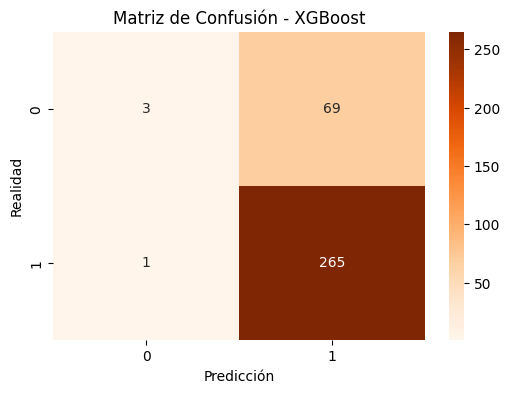

In [27]:
# 1. Instalar la librería directamente desde el notebook
!pip install xgboost

import xgboost as xgb
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Configurar el modelo XGBoost
# Usamos los mismos datos X_train y y_train que ya tenemos en memoria
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric='logloss'
)

# 3. Entrenar
print("Entrenando XGBoost...")
xgb_model.fit(X_train, y_train)

# 4. Predicciones
y_pred_xgb = xgb_model.predict(X_test)

# 5. Resultados
print("\n--- Evaluación: XGBoost ---")
print(classification_report(y_test, y_pred_xgb))

# 6. Matriz de Confusión
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Oranges')
plt.title('Matriz de Confusión - XGBoost')
plt.ylabel('Realidad')
plt.xlabel('Predicción')
plt.show()

Entrenando Red Neuronal (MLP)...

--- Evaluación: Red Neuronal MLP ---
              precision    recall  f1-score   support

           0       0.80      0.06      0.10        72
           1       0.80      1.00      0.88       266

    accuracy                           0.80       338
   macro avg       0.80      0.53      0.49       338
weighted avg       0.80      0.80      0.72       338



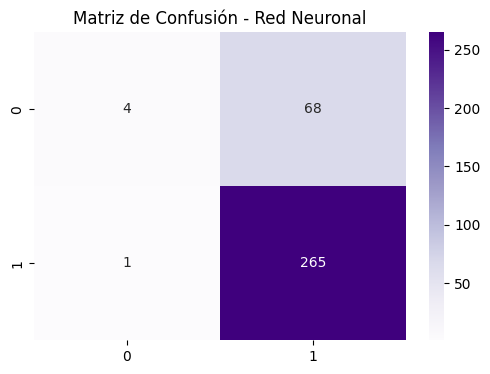

In [29]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Escalar los datos (Las redes neuronales lo necesitan para converger)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Configurar la Red Neuronal (MLP)
# Esta red tiene 2 capas ocultas de 50 y 20 neuronas
mlp_model = MLPClassifier(
    hidden_layer_sizes=(50, 20), 
    max_iter=500, 
    random_state=42,
    activation='relu',
    solver='adam'
)

# 3. Entrenar
print("Entrenando Red Neuronal (MLP)...")
mlp_model.fit(X_train_scaled, y_train)

# 4. Predicciones
y_pred_mlp = mlp_model.predict(X_test_scaled)

# 5. Resultados
print("\n--- Evaluación: Red Neuronal MLP ---")
print(classification_report(y_test, y_pred_mlp))

# 6. Matriz de Confusión
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_mlp), annot=True, fmt='d', cmap='Purples')
plt.title('Matriz de Confusión - Red Neuronal')
plt.show()